In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Downloads/bridges.csv")

In [3]:
#Assumptions
#bridge data is correct and can be verified at a later time as they are physical structures if question arise
#will use std from df.describe to see how much of the data is within range

In [4]:
df.head()

,Id,river,location,erected,purpose,length,lanes,clear-g,t-or-d,material,span,rel-l,type
0,E1,M,3.0,1818,HIGHWAY,NaN,2.0,N,THROUGH,WOOD,SHORT,S,WOOD
1,E2,A,25.0,1819,HIGHWAY,1037.0,2.0,N,THROUGH,WOOD,SHORT,S,WOOD
2,E3,A,39.0,1829,AQUEDUCT,NaN,1.0,N,THROUGH,WOOD,NaN,S,WOOD
3,E5,A,29.0,1837,HIGHWAY,1000.0,2.0,N,THROUGH,WOOD,SHORT,S,WOOD
4,E6,M,23.0,1838,HIGHWAY,NaN,2.0,N,THROUGH,WOOD,NaN,S,WOOD


In [5]:
#13 columns will check on shape to verify

In [6]:
df.shape

(108, 13)

In [7]:
#has 108 rows with 13 columns

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Id        108 non-null    str    
 1   river     108 non-null    str    
 2   location  107 non-null    float64
 3   erected   108 non-null    int64  
 4   purpose   108 non-null    str    
 5   length    81 non-null     float64
 6   lanes     92 non-null     float64
 7   clear-g   106 non-null    str    
 8   t-or-d    102 non-null    str    
 9   material  106 non-null    str    
 10  span      92 non-null     str    
 11  rel-l     103 non-null    str    
 12  type      106 non-null    str    
dtypes: float64(3), int64(1), str(9)
memory usage: 14.7 KB


In [9]:
#there are missing values at location (1), length (27),lanes (16), clear g (2), t or d (6),material (2), span (16), rel (5), and type (2)

In [10]:
df.describe()

,location,erected,length,lanes
count,107.000000,108.000000,81.000000,92.000000
mean,25.978505,1905.314815,1567.469136,2.630435
std,13.665871,37.173664,747.491523,1.164657
min,1.000000,1818.000000,804.000000,1.000000
25%,15.500000,1884.000000,1000.000000,2.000000
50%,27.000000,1903.000000,1300.000000,2.000000
75%,37.500000,1928.000000,2000.000000,4.000000
max,52.000000,1986.000000,4558.000000,6.000000


In [11]:
#find out if there are extreme outliers

In [12]:
long_length = df[df['length'] > 2000]

In [13]:
print(long_length)

       Id river  location  erected  purpose  length  lanes clear-g   t-or-d  \
31    E34     O      41.0     1888       RR  4558.0    2.0       G  THROUGH   
41    E42     M       9.0     1895  HIGHWAY  2367.0    2.0       G  THROUGH   
44    E46     A      37.0     1897       RR  4000.0    2.0       G     DECK   
45    E45     M      14.0     1897       RR  2264.0    NaN       G  THROUGH   
52    E87     A      35.0     1903       RR  3000.0    2.0       G  THROUGH   
64    E92     M      10.0     1914       RR  2210.0    NaN       G  THROUGH   
65    E61     O      41.0     1915       RR  2822.0    2.0       G  THROUGH   
67    E62     A      37.0     1918       RR  2300.0    2.0       N     DECK   
68    E63     A      31.0     1920       RR  2122.0    2.0       G  THROUGH   
71    E66     A      32.0     1924  HIGHWAY  2365.0    4.0       G  THROUGH   
76    E72     M       5.0     1927  HIGHWAY  2663.0    4.0       N     DECK   
78    E75     A      30.0     1928  HIGHWAY  2678.0 

In [14]:
#trying to see how extreme the values are above the 75% for std and can assume these longer briges are related to railroad (RR) and wouldn't be consider extreme.  But possible assumption would be outside of this range could prove to be an outlier

In [15]:
df.isnull().sum()

Id           0
river        0
location     1
erected      0
purpose      0
length      27
lanes       16
clear-g      2
t-or-d       6
material     2
span        16
rel-l        5
type         2
dtype: int64

In [16]:
import seaborn as sns

<Axes: >

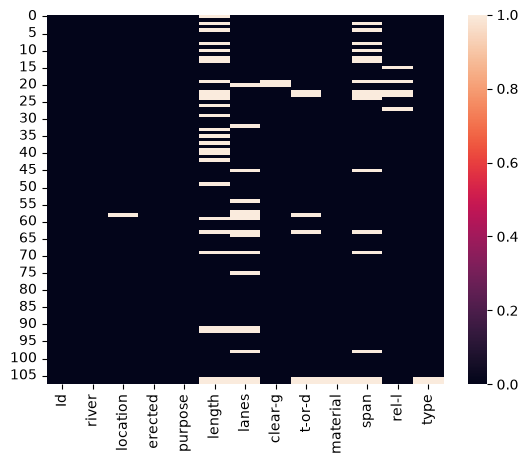

In [17]:
sns.heatmap(df.isnull())

In [18]:
print(df[df['span']=='SHORT'][['Id','span','length']])

     Id   span  length
0    E1  SHORT     NaN
1    E2  SHORT  1037.0
3    E5  SHORT  1000.0
6    E8  SHORT  1000.0
7    E9  SHORT  1500.0
16  E18  SHORT  1200.0
21  E22  SHORT  1200.0
33  E36  SHORT     NaN
38   E4  SHORT  1092.0


In [19]:
short_bridge=df[df['span']=='SHORT']

In [20]:
print(short_bridge.describe())

        location      erected       length     lanes
count   9.000000     9.000000     7.000000  9.000000
mean   23.555556  1854.000000  1147.000000  2.000000
std    13.172994    28.057976   177.280381  0.866025
min     3.000000  1818.000000  1000.000000  1.000000
25%    24.000000  1837.000000  1018.500000  2.000000
50%    27.000000  1846.000000  1092.000000  2.000000
75%    28.000000  1876.000000  1200.000000  2.000000
max    45.000000  1892.000000  1500.000000  4.000000


In [21]:
#need to check for what are short bridges with length min - 1000 max - 1500

In [22]:
print(df[df['span']=='MEDIUM'][['Id','span','length']])

        Id    span  length
5       E7  MEDIUM   990.0
9      E11  MEDIUM  1000.0
11     E14  MEDIUM  1200.0
14     E16  MEDIUM  1030.0
15     E17  MEDIUM  1000.0
17     E19  MEDIUM  1000.0
18     E20  MEDIUM  1000.0
25     E26  MEDIUM  1150.0
26     E30  MEDIUM     NaN
27     E29  MEDIUM  1080.0
28     E28  MEDIUM  1000.0
29     E32  MEDIUM     NaN
30     E31  MEDIUM  1161.0
32     E33  MEDIUM  1120.0
34     E35  MEDIUM  1000.0
35     E38  MEDIUM     NaN
36     E37  MEDIUM  1350.0
37     E39  MEDIUM     NaN
39     E40  MEDIUM     NaN
40     E41  MEDIUM     NaN
46     E47  MEDIUM  2000.0
47     E58  MEDIUM  1200.0
48     E48  MEDIUM  2000.0
50     E49  MEDIUM  1850.0
51     E95  MEDIUM  1300.0
52     E87  MEDIUM  3000.0
53     E51  MEDIUM  1417.0
55     E89  MEDIUM  1200.0
56     E53  MEDIUM   965.0
58     E54  MEDIUM  1240.0
59     E56  MEDIUM     NaN
64     E92  MEDIUM  2210.0
68     E63  MEDIUM  2122.0
70     E64  MEDIUM   885.0
71     E66  MEDIUM  2365.0
72     E70  MEDIUM   860.0
7

In [23]:
medium_bridge=df[df['span']=='MEDIUM']
print(medium_bridge.describe())

        location      erected       length      lanes
count  52.000000    53.000000    44.000000  46.000000
mean   24.609615  1907.207547  1414.500000   2.608696
std    11.578941    29.516852   583.565444   1.021508
min     3.000000  1840.000000   840.000000   2.000000
25%    17.000000  1889.000000  1000.000000   2.000000
50%    26.000000  1903.000000  1180.500000   2.000000
75%    32.000000  1928.000000  1812.500000   4.000000
max    52.000000  1969.000000  3000.000000   6.000000


In [24]:
#some "impossible" data where a medium bridge is min - 840 and max is 3000

In [25]:
print(df[df['span']=='LONG'][['Id','span','length']])

       Id  span  length
20    E23  LONG  1245.0
31    E34  LONG  4558.0
41    E42  LONG  2367.0
42    E44  LONG     NaN
43    E43  LONG  1040.0
44    E46  LONG  4000.0
49    E94  LONG     NaN
54    E50  LONG  1154.0
57    E52  LONG  1504.0
60    E55  LONG  1730.0
61    E57  LONG  1620.0
62    E59  LONG  1652.0
65    E61  LONG  2822.0
66    E60  LONG  1000.0
67    E62  LONG  2300.0
74   E101  LONG  1770.0
77    E67  LONG  1330.0
82    E78  LONG  1365.0
83    E77  LONG  1450.0
84    E76  LONG  1500.0
85    E93  LONG  1690.0
90   E103  LONG  2160.0
95    E81  LONG  2423.0
96    E80  LONG  1031.0
97    E88  LONG  2300.0
99   E102  LONG  1700.0
100   E83  LONG  1000.0
102   E85  LONG  2213.0
104   E91  LONG  3756.0
105   E90  LONG   950.0


In [26]:
long_bridge=df[df['span']=='LONG']
print(long_bridge.describe())

        location     erected       length      lanes
count  30.000000    30.00000    28.000000  27.000000
mean   26.033333  1925.10000  1915.357143   3.185185
std    17.697620    27.20592   925.831247   1.387777
min     1.000000  1876.00000   950.000000   2.000000
25%     9.000000  1903.25000  1308.750000   2.000000
50%    30.000000  1922.50000  1671.000000   2.000000
75%    41.750000  1949.50000  2300.000000   4.000000
max    49.000000  1978.00000  4558.000000   6.000000


In [27]:
# longest bridge at min is 950 and max is at 4558, there seems to be a crossing of c=bounderies between the medium and long bridges

In [28]:
missing_length = df[df['length'].isnull()]

In [29]:
print(missing_length)

       Id river  location  erected   purpose  length  lanes clear-g   t-or-d  \
0      E1     M       3.0     1818   HIGHWAY     NaN    2.0       N  THROUGH   
2      E3     A      39.0     1829  AQUEDUCT     NaN    1.0       N  THROUGH   
4      E6     M      23.0     1838   HIGHWAY     NaN    2.0       N  THROUGH   
8     E10     A      39.0     1848  AQUEDUCT     NaN    1.0       N     DECK   
10    E12     A      39.0     1853        RR     NaN    2.0       N     DECK   
12    E13     A      33.0     1856   HIGHWAY     NaN    2.0       N  THROUGH   
13    E15     A      28.0     1857        RR     NaN    2.0       N  THROUGH   
19    E21     M      16.0     1874        RR     NaN    2.0     NaN  THROUGH   
22    E24     O      45.0     1878        RR     NaN    2.0       G      NaN   
23    E25     M      10.0     1882        RR     NaN    2.0       G      NaN   
24    E27     A      39.0     1883        RR     NaN    2.0       G  THROUGH   
26    E30     A      31.0     1884      

In [30]:
#these are the isolated values of missing legth that would need to be investigated than filling out since 27 out of 108 values is almost 25% of the information is missing.  Filling in values will skew data be it median or mean will not work
# Will need to investigate or followup on bridge length as this will introduce bias if not properly looked at.  Will keep current values until more information is present